# Variable Star Distance — Progressive Build

A step-by-step distance pipeline for a variable star. The star's type (SX
Phe, RR Lyrae, Cepheid, eclipsing binary, ...) is not assumed up front — the
period–luminosity relation, absolute magnitude, and any type-specific
assumptions get layered in once the type is known or hypothesized.


## The Physics: From Flux to Distance

Every distance measurement here traces back to one relationship: how bright a
star appears depends on how much light it puts out and how far away it is.

**Flux and luminosity.** A star radiates a total luminosity $L$ (energy per
second) equally in all directions. At distance $d$, that light has spread out
over the surface of a sphere of area $4\pi d^2$, so the flux $f$ (energy per
second, per unit area) we receive is:

$$ f = \frac{L}{4\pi d^2} $$

This is the inverse-square law: flux falls off as the square of distance —
double the distance, receive a quarter of the light — regardless of what kind
of star it is.

**From flux to magnitudes.** Astronomical magnitudes are a logarithmic flux
scale (Pogson's law): $m = -2.5\log_{10}(f) + \text{const}$. Compare the
star's actual apparent magnitude $m$ (its flux $f$ at its real distance $d$)
to its absolute magnitude $M$ (the magnitude it *would* have if placed at the
standard reference distance of 10 pc, flux $F_{10}$):

$$ m - M = -2.5\log_{10}\!\left(\frac{f}{F_{10}}\right) $$

Since $f \propto 1/d^2$ (from above) and $F_{10} \propto 1/(10\,\mathrm{pc})^2$,
the luminosity $L$ cancels out of the ratio $f/F_{10}$ entirely, leaving only
distance:

$$ \frac{f}{F_{10}} = \left(\frac{10\,\mathrm{pc}}{d}\right)^{\!2}
   \quad\Longrightarrow\quad m - M = 5\log_{10}(d) - 5 $$

This is the **distance modulus**. Solved for distance (in parsecs):

$$ d = 10^{\,(m - M + 5)/5} $$

$m$ is measurable directly — point a telescope at the star and measure its
flux. $M$ is the problem: it's a property of the star itself, not of us, and
nothing about observing the star's *apparent* brightness tells you how far
away it is without already knowing $M$.


## The Challenge of Measuring Luminosity

You can't point a telescope at a star and read off its luminosity or absolute
magnitude directly — what you measure is flux, and the inverse-square law
above shows flux depends on *both* luminosity and distance at once. A single
flux measurement can't tell you how much of "faint" is "far away" versus "not
very luminous" — to get $M$ you need $d$, but $d$ is exactly what you're
trying to find. That circularity is the deadlock this whole method exists to
break.

**How it was broken: relative, not absolute, brightness.** The breakthrough
came from Henrietta Swan Leavitt at Harvard College Observatory, cataloging
thousands of variable stars in the Small Magellanic Cloud (1908–1912). Every
star in the SMC sits at essentially the same distance from us — the cloud's
own size is negligible next to how far away it is as a whole — so
*differences* in apparent brightness among SMC Cepheids had to be differences
in true luminosity, not distance. Leavitt found that the brighter Cepheids
pulsed more slowly: a clean relationship between period and luminosity,
discovered without ever knowing the actual distance to a single one of them.

That gave the *shape* of the relation (the slope) but not its *zero-point* —
where the line sits in absolute terms — since the SMC's own distance wasn't
yet known. Pinning down the zero-point took decades of further calibration:
statistical parallax, main-sequence fitting in star clusters containing
calibrator variables, and eventually direct geometric parallax from missions
like Hipparcos and Gaia, which measure distance without relying on any
period–luminosity assumption at all. Modern P–L zero-points — including the
SX Phe relation used below — ultimately trace back to Gaia parallaxes of
nearby calibrator stars.

**Why every class of pulsator has its own relation.** A period–luminosity
relation isn't one universal law — it falls out of the physics of *why* a
star pulsates (chiefly the opacity-driven κ-mechanism, sensitive to a star's
mass, radius, temperature, and evolutionary state), so different classes land
on different lines: classical Cepheids (young, massive, Population I), RR
Lyrae (old, lower-mass, Population II — luminosity depends more on
metallicity than period), and SX Phe (evolved low-mass Population II stars
pulsating in a regime that mimics young Cepheids) each have their own slope,
zero-point, and scatter, calibrated independently the same Leavitt-style way.
That's why this notebook keeps its relations in a registry keyed by class
rather than one hardcoded formula — applying the wrong class's relation to a
star gives you a confidently wrong distance, not an approximately right one.


## What This Notebook Needs

Given a calibrated period–luminosity relation to stand in for the $M$ we
can't measure directly, here's how this notebook gets from your observations
to a distance.

**Where the data comes from.** `REPORT_PATH` (in Configuration below) points
at photometry for the target star, from either of two AAVSO sources:

- **A report you generated yourself** — an AAVSO Extended Format file exported
  from VPhot or ASTAP after reducing your own images, transformed or not.
  This is what the notebook has been tested against so far.
- **A download of existing observations from the AAVSO International
  Database** — useful for a star you haven't imaged yourself, or when you
  want a longer public baseline than one of your own sessions provides.

Both are meant to work as a straight drop-in for `REPORT_PATH`; we'll verify
that once we get to Section 3.

**The chain, start to finish.** The only real *input* here is a set of
magnitude-at-time observations, extracted from that report. Everything else
is derived from those observations, or from something derived from them:

1. **Observations** — (time, magnitude) pairs extracted from the report.
2. **$P$** (period) — recovered from the observations via a Lomb–Scargle
   periodogram.
3. **$m$** (apparent magnitude) — also computed from the observations, but
   using $P$: fold them on $P$ and take the intensity mean over one cycle.
4. **$M$** (absolute magnitude) — computed from $P$ via a period–luminosity
   relation, since $M$ itself can't be measured directly (previous section).
5. **$d$** (distance) — computed from $m$ and $M$ via the distance modulus.

| Quantity | Derived from |
|---|---|
| Observations | the AAVSO report |
| $P$ | observations, via Lomb–Scargle |
| $m$ | observations, folded on $P$ (intensity mean) |
| $M$ | $P$, via a period–luminosity relation |
| $d$ | $m$ and $M$, via the distance modulus |

The sections below build each one in turn, in that order: period from
observations, absolute magnitude from period, apparent magnitude from
observations, then distance.


## 1 · Imports

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from astropy.timeseries import LombScargle

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(fig, name, dpi=300):
    """Save a figure as a presentation-ready PNG (e.g. for a slide deck).
    `name` is sanitized to a safe filename -- AAVSO NAME fields sometimes carry
    free text (dates, spectral type, ...) rather than a clean star name."""
    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", name).strip("_")
    path = FIGURE_DIR / f"{safe_name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved {path}")
    return path


print("imports ok")


imports ok


## 2 · Configuration

Everything you'd change for a different report, star, or band lives here —
one place to look before a run, rather than hunting through cells below.


In [2]:
# Example: a full ~4-hour session (218 pts), enough to see several cycles.
# Swap in any AAVSO Extended Format report -- transformed or not, either works.
REPORT_PATH = "/Users/jwatts/Documents/astrophotography/Photometry/CYAqr-09052026/Report/AAVSOReport_CY-Aqr_VBR_110Comp_104Check_TA_SA114.txt"
BAND = "V"
TARGET_NAME = None          # only needed if the report covers more than one star
KNOWN_PERIOD = 0.06103845   # literature period (days), if you have one, to mark on the plot -- set to None otherwise
STAR_LABEL = None           # clean name for plot titles/filenames -- leave None to use the
                            # report's own NAME field; set only if that field carries free
                            # text (dates, spectral type, ...) rather than a bare star name

print(f"REPORT_PATH = {REPORT_PATH}")
print(f"BAND = {BAND}, TARGET_NAME = {TARGET_NAME}, KNOWN_PERIOD = {KNOWN_PERIOD}, STAR_LABEL = {STAR_LABEL}")


REPORT_PATH = /Users/jwatts/Documents/astrophotography/Photometry/CYAqr-09052026/Report/AAVSOReport_CY-Aqr_VBR_110Comp_104Check_TA_SA114.txt
BAND = V, TARGET_NAME = None, KNOWN_PERIOD = 0.06103845, STAR_LABEL = None


In [3]:
# --- period -> absolute magnitude relations ---------------------------------
# Registry of linear P-L relations (M = a + b*log10(P)). Add a new entry here
# to make it selectable via RELATION_NAME below -- see Section 6 for the
# uncertainty model these fields feed into. period_range is the class range
# this relation is actually calibrated over, used for the Error Analysis plot.
PL_RELATIONS = {
    "SXPhe_CohenSarajedini2012": {
        "label": "SX Phe (Cohen & Sarajedini 2012)",
        "a": -1.640, "a_err": 0.110,    # intercept (zero-point)
        "b": -3.389, "b_err": 0.090,    # slope
        "sigma_intrinsic": 0.20,        # star-to-star scatter around the mean line (mag)
        "reference": "Cohen & Sarajedini (2012), M_V = a + b*log10(P_fundamental [days])",
        "period_range": (0.02, 0.20),   # days -- the SX Phe regime this relation covers
    },
}

RELATION_NAME = "SXPhe_CohenSarajedini2012"   # must be a key in PL_RELATIONS above

print(f"RELATION_NAME = {RELATION_NAME} -> {PL_RELATIONS[RELATION_NAME]['label']}")


RELATION_NAME = SXPhe_CohenSarajedini2012 -> SX Phe (Cohen & Sarajedini 2012)


## 3 · Load an AAVSO report

Reads photometry from either AAVSO source described above, auto-detected by
format:

- **Extended Format** (VPhot/ASTAP export, transformed or not) — metadata
  lines start with `#`; the column header is itself a `#`-prefixed line. A
  `TransformApplier` report keeps each original untransformed row as a
  commented-out line directly above its `TRANS=YES` replacement, and those,
  along with the TA's own `# Tbv=...` banner lines, are skipped so only the
  live data rows come through.
- **AAVSO International Database (AID) download** — an ordinary CSV with a
  plain header row (`JD`, `Magnitude`, `Band`, `Star Name`, ...), no leading
  `#` lines at all.

Detection is just "does the first non-blank line start with `#`" — Extended
Format always does, an AID download never does. Either way, the result is
normalized onto the same column names (`DATE`, `MAG`, `MERR`, `FILT`, `NAME`)
so everything downstream works the same regardless of source.


In [4]:
def load_aavso_report(path):
    """Parse AAVSO photometry from either source format, auto-detected, and
    normalized onto a common set of columns (NAME, DATE, MAG, MERR, FILT).
    """
    path = Path(path)
    first_line = next((l for l in path.read_text().splitlines() if l.strip()), "")
    if first_line.startswith("#"):
        return _load_extended_format(path)
    return _load_aid_download(path)


def _load_extended_format(path):
    """AAVSO Extended Format (VPhot/ASTAP export, transformed or not) -- see
    the markdown above for how its '#'-prefixed lines are handled."""
    delim = ","
    header = None
    data_lines = []

    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        if line.startswith("#DELIM="):
            delim = line.split("=", 1)[1].strip()
        elif line.startswith("#NAME" + delim):
            header = line.lstrip("#").split(delim)
        elif line.startswith("#"):
            continue
        else:
            data_lines.append(line.split(delim))

    if header is None:
        raise ValueError(f"Could not find column header line in {path}")

    df = pd.DataFrame(data_lines, columns=header)
    for col in ["DATE", "MAG", "MERR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def _load_aid_download(path):
    """A plain CSV downloaded from the AAVSO International Database. Renamed
    onto the same column names the Extended Format loader produces, so
    get_band_series works unchanged regardless of source."""
    df = pd.read_csv(path, low_memory=False)
    df = df.rename(columns={
        "JD": "DATE",
        "Magnitude": "MAG",
        "Uncertainty": "MERR",
        "Band": "FILT",
        "Star Name": "NAME",
    })
    for col in ["DATE", "MAG", "MERR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def get_band_series(df, band, target_name=None):
    """Time (JD) and magnitude arrays for one filter, sorted and cleaned,
    ready for period-finding. `target_name` narrows to one star if the report
    covers more than one (rare for a single-target AAVSO submission).
    """
    sel = df["FILT"] == band
    if target_name is not None:
        sel &= df["NAME"] == target_name
    d = df.loc[sel].dropna(subset=["DATE", "MAG"]).sort_values("DATE")
    meta = {
        "target": target_name or (df["NAME"].iloc[0] if len(df) else None),
        "band": band,
        "n_points": len(d),
    }
    return d["DATE"].to_numpy(), d["MAG"].to_numpy(), meta


def plot_raw_data(times, mags, title):
    """Magnitude vs. time for the loaded band -- a first look at the raw
    observations before any period-finding, so gaps, outliers, or trends are
    visible by eye up front."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(times, mags, s=8, alpha=0.5, color="steelblue")
    ax.invert_yaxis()
    ax.set(xlabel="time (JD)", ylabel="magnitude", title=title)
    fig.tight_layout()
    return fig, ax


print("load_aavso_report + get_band_series + plot_raw_data defined")


load_aavso_report + get_band_series + plot_raw_data defined


## 4 · Step 1 — Period from observations (Lomb–Scargle)

AAVSO data isn't evenly sampled — clouds, meridian flips, one visit a night —
so a plain Fourier transform doesn't apply cleanly. **Lomb–Scargle** is built
for exactly that case: it tests a dense grid of candidate frequencies
(equivalently, candidate periods) and scores each one by how well a sinusoid
at that frequency fits the scattered data. That score is called *power* — high
power means the data fold into a strong, coherent repeating pattern at that
period; low power means they don't.

**What the function returns.** `LombScargle(times, mags).autopower(...)`
returns two equal-length arrays: `freq` (the frequency grid it tested, in
cycles/day) and `power` (the fit quality at each frequency). That pair *is*
the periodogram — there's no single "period" value in the return, just power
as a function of frequency.

**How to get the period from it.** Find the index of the highest power
(`argmax(power)`), then invert that frequency: `period = 1 / freq[argmax(power)]`.
Inverting the whole `freq` array the same way (`1 / freq`) gives a period axis
for plotting the periodogram directly, which is what the cell below does.

Because the star's type isn't assumed, the search window (`p_min`/`p_max`)
defaults from the data itself rather than a class-specific pulsation range:
`p_max` defaults to half the observed time baseline (Lomb–Scargle can't
meaningfully constrain a period longer than that), and `p_min` defaults to
0.01 d (~14 min) — override either if you have reason to expect something
outside that window (e.g. a slower pulsator or an eclipsing binary). If the
report's time baseline is too short to even reach `p_min` (e.g. a short
test/calibration upload rather than a full session), the function raises a
clear error instead of silently returning a meaningless result.


In [5]:
def find_period(times, mags, p_min=None, p_max=None, samples_per_peak=10):
    """Recover the dominant period via Lomb-Scargle. Returns (best_period,
    diagnostics) -- see the markdown above for what's in the periodogram and
    how best_period is derived from it."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)

    baseline = times.max() - times.min()
    if p_max is None:
        p_max = baseline / 2
    if p_min is None:
        p_min = 0.01

    if p_max <= p_min:
        raise ValueError(
            f"time baseline ({baseline*1440:.1f} min) is too short to search "
            f"periods as long as p_min ({p_min*1440:.1f} min) -- need more data, "
            f"or pass an explicit shorter p_min"
        )

    f_min, f_max = 1.0 / p_max, 1.0 / p_min

    ls = LombScargle(times, mags)
    freq, power = ls.autopower(minimum_frequency=f_min, maximum_frequency=f_max,
                               samples_per_peak=samples_per_peak)

    best_idx = int(np.argmax(power))
    best_period = 1.0 / freq[best_idx]

    diag = {
        "freq": freq,
        "power": power,
        "period_grid": 1.0 / freq,
        "best_period": best_period,
        "best_power": power[best_idx],
        "false_alarm_probability": ls.false_alarm_probability(power[best_idx]),
        "p_min": p_min,
        "p_max": p_max,
    }
    return best_period, diag


def plot_periodogram(diag, title, known_period=None):
    """Power vs. period, marking the recovered peak and an optional literature
    reference period."""
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(diag["period_grid"], diag["power"], lw=0.8, color="steelblue")
    ax.axvline(diag["best_period"], color="crimson", lw=1.5,
               label=f"recovered = {diag['best_period']:.6f} d")
    if known_period:
        ax.axvline(known_period, color="green", ls="--", lw=1.5,
                   label=f"literature = {known_period:.6f} d")
    ax.set(xlabel="Period (days)", ylabel="Lomb-Scargle power", title=title)
    ax.legend()
    fig.tight_layout()
    return fig, ax


print("find_period + plot_periodogram defined")


find_period + plot_periodogram defined


## 5 · Run it on a report

Loads the report, plots the raw loaded observations for a first look, then
runs the period search.

CY Aqr: 218 V-band points spanning 0.164 d


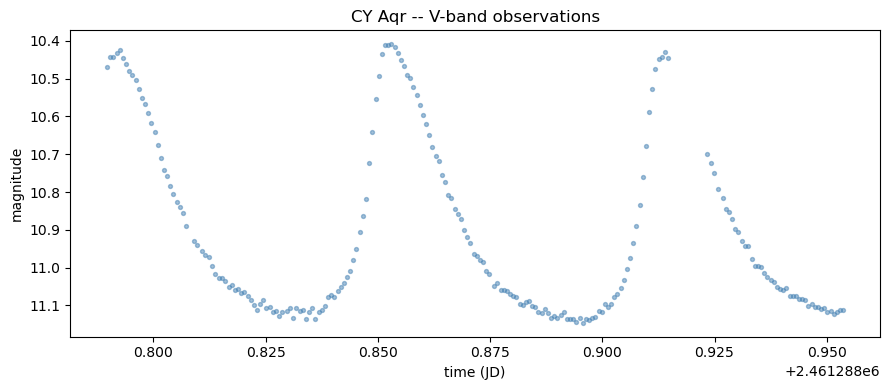

saved figures/rawdata_CY_Aqr_V.png
recovered period : 0.060743 d  (87.469 min)
best-peak power  : 0.8089
false-alarm prob : 5.48e-78
search window    : 0.0100-0.0820 d
literature period: 0.061038 d  (87.895 min)
delta (rec-lit)  : -0.000296 d  (-0.426 min)


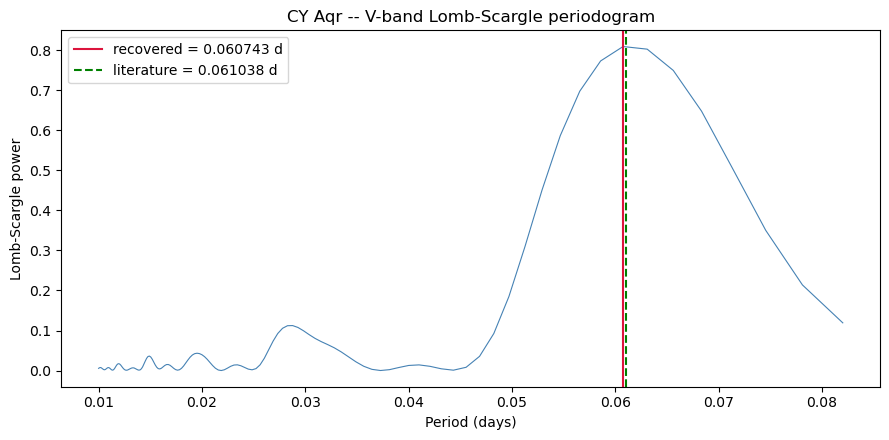

saved figures/periodogram_CY_Aqr_V.png


In [6]:
df = load_aavso_report(REPORT_PATH)
times, mags, meta = get_band_series(df, BAND, target_name=TARGET_NAME)
label = STAR_LABEL or meta["target"]

print(f"{meta['target']}: {meta['n_points']} {BAND}-band points"
     + (f" spanning {times.max()-times.min():.3f} d" if meta["n_points"] else ""))

if meta["n_points"] == 0:
    print(f"No {BAND}-band points in this report to plot.")
else:
    fig, ax = plot_raw_data(times, mags, title=f"{label} -- {BAND}-band observations")
    plt.show()
    save_figure(fig, f"rawdata_{label}_{BAND}")

if meta["n_points"] < 2:
    print(f"Not enough {BAND}-band points in this report to run Lomb-Scargle.")
else:
    try:
        period, diag = find_period(times, mags)
    except ValueError as exc:
        period, diag = None, None
        print(f"Could not determine a period: {exc}")

    if diag is not None:
        print(f"recovered period : {period:.6f} d  ({period*1440:.3f} min)")
        print(f"best-peak power  : {diag['best_power']:.4f}")
        print(f"false-alarm prob : {diag['false_alarm_probability']:.2e}")
        print(f"search window    : {diag['p_min']:.4f}-{diag['p_max']:.4f} d")
        if KNOWN_PERIOD:
            delta = period - KNOWN_PERIOD
            print(f"literature period: {KNOWN_PERIOD:.6f} d  ({KNOWN_PERIOD*1440:.3f} min)")
            print(f"delta (rec-lit)  : {delta:+.6f} d  ({delta*1440:+.3f} min)")

        fig, ax = plot_periodogram(
            diag, title=f"{label} -- {BAND}-band Lomb-Scargle periodogram",
            known_period=KNOWN_PERIOD,
        )
        plt.show()
        save_figure(fig, f"periodogram_{label}_{BAND}")


## 6 · Step 2 — Absolute magnitude from period (P–L relation)

A period–luminosity (P–L) relation says how bright a star truly is (its
absolute magnitude) as a function of its pulsation period. Different classes
of pulsating variable — SX Phe, classical Cepheids, RR Lyrae, ... — each have
their own relation, but many are well approximated by a straight line in
log-period space:

    M = a + b · log10(P)

where `a` is the intercept (zero-point) and `b` is the slope, both empirically
calibrated against stars with independently known distances (e.g. via Gaia
parallax).

**Selecting a relation.** `PL_RELATIONS`, defined in the Configuration section
above, is a registry of these linear relations by name. Right now it holds
only the SX Phe relation from Cohen & Sarajedini (2012) — the one already used
elsewhere in this project for CY Aqr — deliberately: coefficients for other
classes aren't verified anywhere in this repo yet, and a presentation isn't
the place to guess at them. `RELATION_NAME` picks which entry to apply. To add
another class's relation once you have a sourced value for it, add an entry to
`PL_RELATIONS` with its own `a`/`a_err`/`b`/`b_err`/`sigma_intrinsic`, then
point `RELATION_NAME` at it — no other code changes needed.

**What `period_to_absmag` returns.** A tuple `(M, M_err)` — the absolute
magnitude and its 1-sigma uncertainty. The uncertainty combines two things
that answer different questions: how well the *mean* relation itself is known
(from `a_err`/`b_err`, plus your period's own uncertainty if you supply one),
and — when `include_intrinsic=True` (the default) — the relation's intrinsic
scatter (`sigma_intrinsic`), which is how much one real star typically
deviates from the mean line even with the mean line known perfectly. For
predicting a single star's own distance, the intrinsic-scatter version is the
honest number: it dominates, and represents the astrophysical floor of this
whole exercise, not just calibration error.


In [7]:
def period_to_absmag(period, relation_name, period_err=0.0, include_intrinsic=True):
    """Absolute magnitude from a period via the linear P-L relation named
    `relation_name` in PL_RELATIONS. Returns (M, M_err) -- see the markdown
    above for what the two uncertainty components mean."""
    rel = PL_RELATIONS[relation_name]
    a, a_err = rel["a"], rel["a_err"]
    b, b_err = rel["b"], rel["b_err"]
    sigma_intrinsic = rel["sigma_intrinsic"]

    logP = np.log10(period)
    M = a + b * logP

    sig_logP = period_err / (period * np.log(10))
    var_cal = a_err**2 + (logP * b_err)**2 + (b * sig_logP)**2
    var_M = var_cal + (sigma_intrinsic**2 if include_intrinsic else 0.0)
    return M, np.sqrt(var_M)


print("period_to_absmag defined")


period_to_absmag defined


## 7 · Run it

In [8]:
if period is None:
    print("No period available from Stage 1 -- run that cell successfully first.")
else:
    rel = PL_RELATIONS[RELATION_NAME]
    M_V, M_err = period_to_absmag(period, RELATION_NAME)
    M_V_cal, M_err_cal = period_to_absmag(period, RELATION_NAME, include_intrinsic=False)

    print(f"relation          : {rel['label']}")
    print(f"reference         : {rel['reference']}")
    print(f"period used       : {period:.6f} d")
    print(f"M_V (+ intrinsic) : {M_V:.3f} +/- {M_err:.3f}")
    print(f"M_V (calibration) : {M_V_cal:.3f} +/- {M_err_cal:.3f}")


relation          : SX Phe (Cohen & Sarajedini 2012)
reference         : Cohen & Sarajedini (2012), M_V = a + b*log10(P_fundamental [days])
period used       : 0.060743 d
M_V (+ intrinsic) : 2.483 +/- 0.253
M_V (calibration) : 2.483 +/- 0.155


## 8 · Step 3 — Apparent magnitude from observations (fold and mean)

The naive approach — just average every magnitude reading — is biased two
ways, and folding on the period fixes both.

**Bias 1: averaging happens in the wrong space.** Magnitudes are a
logarithmic scale; flux (brightness) is linear. The average of a set of
magnitudes is *not* the magnitude of the average flux — converting to flux,
averaging, then converting back gives a different (and correct) answer. This
is the same "intensity mean" idea used throughout this project: what you want
is the mean brightness the star actually emitted, not the mean of a nonlinear
transform of it.

**Bias 2: raw samples aren't spread evenly across the cycle.** A pulsating
star spends more real time near some phases of its cycle than others (e.g.
lingering longer near minimum), and your own observing cadence adds further
unevenness on top of that. A plain average silently over-weights whichever
phase happens to have more data points — by luck of scheduling, not by
anything physical.

**How folding fixes both.** `fold_and_mean` uses `period` to map every
observation's timestamp onto a phase from 0 to 1 (`((t - t0) / period) % 1`),
bins the phases uniformly, flux-averages *within* each bin, and only then
averages the bins together — so every part of the cycle counts once,
regardless of how many raw points happened to land there. Empty bins (phases
with no coverage at all) are skipped rather than invented, and reported as a
coverage fraction so any gap stays visible rather than silently smoothed over.

**What it returns.** A tuple `(V_mean, diag)`: `V_mean` is the intensity-mean
apparent magnitude — the answer to use as $m$. `diag` carries everything used
to compute it, including `V_naive` (the plain mean, for comparison) and
`coverage`/`n_empty` (how much of the phase cycle was actually observed).


In [9]:
def fold_and_mean(times, mags, period, t0=None, n_bins=20):
    """Intensity-mean apparent magnitude over one folded pulsation cycle.
    Returns (V_mean, diag) -- see the markdown above for what's in diag and
    why V_mean isn't just mags.mean()."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)

    if t0 is None:
        t0 = times.min()

    phase = ((times - t0) / period) % 1.0
    flux = 10**(-0.4 * mags)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(phase, edges) - 1, 0, n_bins - 1)

    bin_flux = np.full(n_bins, np.nan)
    bin_n = np.zeros(n_bins, int)
    for b in range(n_bins):
        sel = idx == b
        bin_n[b] = sel.sum()
        if bin_n[b] > 0:
            bin_flux[b] = flux[sel].mean()

    occupied = bin_n > 0
    mean_flux = np.nanmean(bin_flux[occupied])
    V_mean = -2.5 * np.log10(mean_flux)

    diag = {
        "phase": phase, "mags": mags,
        "bin_centers": 0.5 * (edges[:-1] + edges[1:]),
        "bin_mag": -2.5 * np.log10(bin_flux),
        "bin_n": bin_n, "occupied": occupied,
        "n_empty": int((~occupied).sum()), "coverage": occupied.mean(),
        "V_mean": V_mean, "V_naive": mags.mean(), "period": period,
    }
    return V_mean, diag


def plot_folded(diag, title):
    """Folded light curve with binned means; empty (gap) bins highlighted."""
    bc, bm = diag["bin_centers"], diag["bin_mag"]
    fig, ax = plt.subplots(figsize=(9, 5))
    for shift in (0, 1):
        ax.scatter(diag["phase"] + shift, diag["mags"], s=8, alpha=0.4,
                   color="gray", label="data" if shift == 0 else None)
        ax.plot(bc + shift, bm, "o-", color="crimson",
                label="phase-binned mean" if shift == 0 else None)
    ax.axhline(diag["V_mean"], ls="--", color="navy",
               label=f"intensity mean = {diag['V_mean']:.3f}")
    w = 1.0 / len(bc)
    for c, occ in zip(bc, diag["occupied"]):
        if not occ:
            for shift in (0, 1):
                ax.axvspan(c + shift - w/2, c + shift + w/2, color="orange", alpha=0.2)
    ax.invert_yaxis()
    ax.set(xlabel="phase", ylabel="magnitude", title=title)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


print("fold_and_mean + plot_folded defined")


fold_and_mean + plot_folded defined


## 9 · Run it

intensity mean m : 10.875 V
naive mean m     : 10.911 V  (bias = +0.035)
phase coverage   : 100%  (0 empty bins of 20)


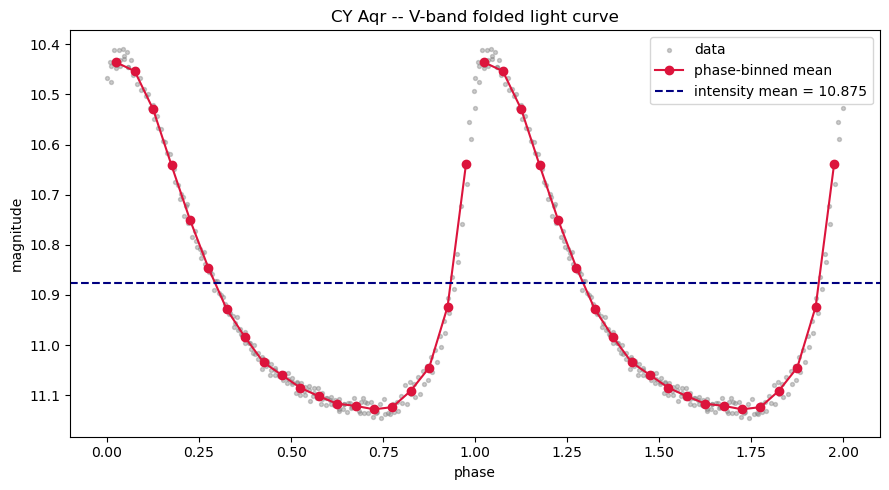

saved figures/folded_CY_Aqr_V.png


In [10]:
if period is None:
    print("No period available from Stage 1 -- run that cell successfully first.")
else:
    m, fold_diag = fold_and_mean(times, mags, period)

    print(f"intensity mean m : {m:.3f} {BAND}")
    print(f"naive mean m     : {fold_diag['V_naive']:.3f} {BAND}  (bias = {fold_diag['V_naive'] - m:+.3f})")
    print(f"phase coverage   : {100*fold_diag['coverage']:.0f}%  "
         f"({fold_diag['n_empty']} empty bins of {len(fold_diag['bin_centers'])})")

    fig, ax = plot_folded(fold_diag, title=f"{label} -- {BAND}-band folded light curve")
    plt.show()
    save_figure(fig, f"folded_{label}_{BAND}")


## 10 · Step 4 — Distance from apparent and absolute magnitude, compared to Gaia

The last step is just solving the distance modulus derived in the Physics
section above for $d$:

$$ d = 10^{\,(m - M + 5)/5} \quad \text{(parsecs)} $$

with an optional extinction term $A_V$ (interstellar dust dimming along the
line of sight) subtracted from the modulus first if you have one — it
defaults to 0 here, since it hasn't been estimated for this sightline.

**What `distance_from_modulus` returns.** A tuple `(d, d_err)`. Distance is
exponential in the modulus, so a fixed uncertainty in magnitudes doesn't map
to a fixed uncertainty in parsecs — the function propagates it properly
(`d_err = d · ln(10)/5 · σ`, where `σ` combines `m_err`, `M_err`, and `A_err`
in quadrature). By default `m_err=0`, since Stage 3 doesn't estimate a formal
uncertainty on the intensity mean — in practice this is fine: `M_err`
(dominated by the relation's own intrinsic scatter, ~0.2 mag) is almost
always far larger than the photometric uncertainty on a well-observed star's
mean magnitude, so `d_err` here is really telling you how well the *relation*
constrains this star's distance, not how well you measured it.

**A sanity check for free.** Gaia measures distance directly via geometric
parallax — no reference to periods, pulsation, or any P–L relation — so
fetching it here costs nothing extra and gives an immediate check on the
distance this notebook just computed. `gaia_crosscheck` (below) resolves the
star via SIMBAD and queries Gaia DR3 for its Bailer-Jones geometric distance,
the statistically preferred estimate over naively inverting parallax (biased
for stars without a large parallax-to-error ratio). This needs the
`astroquery` package (`pip install astroquery` if missing — it isn't part of
this notebook's own Imports, since this is the one part reaching an external
service) and a live connection to Gaia/SIMBAD.


In [11]:
PC_TO_LY = 3.2616  # 1 parsec in light years


def distance_from_modulus(m, M, m_err=0.0, M_err=0.0, A_V=0.0, A_err=0.0):
    """Distance in parsecs from apparent & absolute magnitude, with optional
    extinction correction and propagated 1-sigma uncertainty. Returns
    (d, d_err) -- see the markdown above for what feeds d_err."""
    mu0 = m - M - A_V
    d = 10 ** ((mu0 + 5) / 5)

    sig_mu = np.sqrt(m_err**2 + M_err**2 + A_err**2)
    d_err = d * np.log(10) / 5 * sig_mu
    return d, d_err


def resolve_coords(name):
    """Look up an object's ICRS coordinates by name via SIMBAD."""
    from astroquery.simbad import Simbad
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    res = Simbad.query_object(name)
    if res is None or len(res) == 0:
        raise RuntimeError(f"SIMBAD could not resolve '{name}'")
    # SIMBAD returns RA/Dec; column names vary by astroquery version
    ra_col = "ra" if "ra" in res.colnames else "RA"
    dec_col = "dec" if "dec" in res.colnames else "DEC"
    val_ra, val_dec = res[ra_col][0], res[dec_col][0]
    try:
        c = SkyCoord(float(val_ra) * u.deg, float(val_dec) * u.deg, frame="icrs")
    except (ValueError, TypeError):
        c = SkyCoord(str(val_ra), str(val_dec), unit=(u.hourangle, u.deg), frame="icrs")
    return c.ra.deg, c.dec.deg


def gaia_crosscheck(name=None, source_id=None, ra=None, dec=None, radius_arcsec=3.0):
    """Fetch Gaia DR3 parallax + Bailer-Jones geometric distance for a star.
    Preference: source_id > name (SIMBAD-resolved) > explicit ra/dec. Returns
    a dict -- see the markdown above for why d_bj_geo_pc, not 1000/parallax,
    is the distance to trust."""
    from astroquery.gaia import Gaia

    if source_id is None and name is not None and (ra is None or dec is None):
        ra, dec = resolve_coords(name)
        print(f"SIMBAD resolved '{name}' -> RA {ra:.5f}, Dec {dec:.5f} deg")

    if source_id is not None:
        where = f"g.source_id = {source_id}"
    elif ra is not None and dec is not None:
        r = radius_arcsec / 3600.0
        where = (f"1=CONTAINS(POINT('ICRS', g.ra, g.dec), "
                 f"CIRCLE('ICRS', {ra}, {dec}, {r}))")
    else:
        raise ValueError("provide name, source_id, or ra+dec")

    adql = f"""
    SELECT g.source_id, g.ra, g.dec, g.parallax, g.parallax_error,
           g.phot_g_mean_mag, g.bp_rp,
           bj.r_med_geo, bj.r_lo_geo, bj.r_hi_geo,
           bj.r_med_photogeo, bj.r_lo_photogeo, bj.r_hi_photogeo
    FROM gaiadr3.gaia_source AS g
    LEFT JOIN external.gaiaedr3_distance AS bj
           ON g.source_id = bj.source_id
    WHERE {where}
    ORDER BY g.phot_g_mean_mag ASC
    """
    job = Gaia.launch_job(adql)
    t = job.get_results()
    if len(t) == 0:
        raise RuntimeError("no Gaia source found -- check name/id/coords")
    # if the cone returns several sources, take the brightest -- the target
    # star should dominate any faint neighbor in a 3" cone
    row = t[0]

    plx, plx_err = float(row["parallax"]), float(row["parallax_error"])
    d_plx = 1000.0 / plx
    d_plx_err = d_plx * (plx_err / plx)

    d_bj = float(row["r_med_geo"])
    d_bj_err = (float(row["r_hi_geo"]) - float(row["r_lo_geo"])) / 2

    out = {
        "source_id": int(row["source_id"]),
        "parallax_mas": plx, "parallax_err_mas": plx_err,
        "d_parallax_pc": d_plx, "d_parallax_err_pc": d_plx_err,
        "d_bj_geo_pc": d_bj, "d_bj_geo_err_pc": d_bj_err,
        "d_bj_geo_lo_pc": float(row["r_lo_geo"]), "d_bj_geo_hi_pc": float(row["r_hi_geo"]),
        "G_mag": float(row["phot_g_mean_mag"]), "bp_rp": float(row["bp_rp"]),
    }

    print(f"Gaia DR3 {out['source_id']}")
    print(f"  parallax         = {plx:.4f} +/- {plx_err:.4f} mas")
    print(f"  d (1/plx, naive) = {d_plx:.1f} +/- {d_plx_err:.1f} pc   [biased -- see markdown]")
    print(f"  d (BJ geo)       = {d_bj:.1f} +/- {d_bj_err:.1f} pc  "
         f"[{out['d_bj_geo_lo_pc']:.1f}, {out['d_bj_geo_hi_pc']:.1f}]  <- used below")
    print(f"  G = {out['G_mag']:.3f}, BP-RP = {out['bp_rp']:.3f}")
    return out


print("distance_from_modulus + resolve_coords + gaia_crosscheck defined")


distance_from_modulus + resolve_coords + gaia_crosscheck defined


## 11 · Run it

In [12]:
if period is None:
    print("No period available -- run Stage 1 successfully first.")
else:
    d_pc, d_pc_err = distance_from_modulus(m, M_V, M_err=M_err)
    d_ly, d_ly_err = d_pc * PC_TO_LY, d_pc_err * PC_TO_LY

    print(f"m (apparent)  : {m:.3f}")
    print(f"M (absolute)  : {M_V:.3f} +/- {M_err:.3f}")
    print(f"distance      : {d_pc:.1f} +/- {d_pc_err:.1f} pc")
    print(f"distance      : {d_ly:.1f} +/- {d_ly_err:.1f} ly")

    gaia = gaia_crosscheck(name=label)

    delta_pc = d_pc - gaia["d_bj_geo_pc"]
    delta_pct = 100 * delta_pc / gaia["d_bj_geo_pc"]

    print()
    print(f"distance (this notebook, via P-L relation)  : {d_pc:.1f} +/- {d_pc_err:.1f} pc")
    print(f"distance (Gaia DR3, Bailer-Jones geometric)  : {gaia['d_bj_geo_pc']:.1f} +/- {gaia['d_bj_geo_err_pc']:.1f} pc")
    print(f"delta                                        : {delta_pc:+.1f} pc  ({delta_pct:+.1f}%)")


m (apparent)  : 10.875
M (absolute)  : 2.483 +/- 0.253
distance      : 477.0 +/- 55.6 pc
distance      : 1555.8 +/- 181.4 ly


ModuleNotFoundError: No module named 'astroquery'

## 12 · Error Analysis — M vs. the P–L Relation

Every $M$ used so far was computed *directly* from this star's own period via
the P–L relation (`M = a + b·log10(P)`, Section 6) — by construction, it
can't disagree with the relation. Plotting that point against the relation's
own line is a useful gut-check on how *wide* the relation's uncertainty is at
this period, but it isn't a test of whether the relation is right for this
star.

**A real test needs a second, independent $M$.** Section 11 already fetched
Gaia's distance to this star — measured by pure geometric parallax, with no
reference to pulsation, luminosity, or any P–L relation at all. Combined with
this star's own apparent magnitude $m$ (Section 8), the same distance modulus
from the Physics section, solved the other way, gives that independent value:

$$ M_{\text{Gaia}} = m - 5\log_{10}(d_{\text{Gaia}}) + 5 $$

Plotted at this star's actual period, *this* point has real freedom to land
off the line — how far off, compared to the relation's own uncertainty
bands, is the actual answer to whether this star fits its assumed class.

**What to expect.** Some scatter is normal even for a correctly-classified
star: the relation's ~0.2 mag intrinsic scatter (Section 6) means real SX Phe
stars don't sit exactly on the line just from being SX Phe — that scatter is
baked into the total-uncertainty band, and landing inside it isn't evidence
of anything going wrong. A deviation much larger than that band would be the
interesting case — it would point toward this star's true class, metallicity,
or pulsation mode differing from what the relation assumes, rather than
ordinary scatter.


In [13]:
def plot_pl_relation(relation_name, star_period, star_M, star_M_err, title, extra_point=None):
    """P-L relation line with calibration and total uncertainty bands, plus
    one star's own (period, M) point -- see the markdown above for what this
    plot does and doesn't demonstrate. `extra_point`, if given, is
    (period, M, M_err, label) for a second point (e.g. an independent
    Gaia-derived M) plotted in a different color."""
    rel = PL_RELATIONS[relation_name]
    a, a_err = rel["a"], rel["a_err"]
    b, b_err = rel["b"], rel["b_err"]
    sigma_intrinsic = rel["sigma_intrinsic"]
    p_lo, p_hi = rel["period_range"]

    logP = np.linspace(np.log10(p_lo), np.log10(p_hi), 200)
    M_line = a + b * logP
    sig_cal = np.sqrt(a_err**2 + (logP * b_err) ** 2)
    sig_tot = np.sqrt(sig_cal**2 + sigma_intrinsic**2)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.fill_between(logP, M_line - sig_tot, M_line + sig_tot, color="orange", alpha=0.15,
                    label=f"+/- total (incl. {sigma_intrinsic:.2f} mag intrinsic scatter)")
    ax.fill_between(logP, M_line - sig_cal, M_line + sig_cal, color="steelblue", alpha=0.25,
                    label="+/- calibration only")
    ax.plot(logP, M_line, "-", color="navy", lw=2, label=rel["label"])

    star_label = "this star (from P-L relation)" if extra_point else "this star"
    ax.errorbar([np.log10(star_period)], [star_M], yerr=[star_M_err], fmt="o", color="crimson",
               markersize=9, capsize=5,
               label=f"{star_label} (M = {star_M:.2f} +/- {star_M_err:.2f})")

    if extra_point is not None:
        ep_period, ep_M, ep_M_err, ep_label = extra_point
        ax.errorbar([np.log10(ep_period)], [ep_M], yerr=[ep_M_err], fmt="s", color="seagreen",
                   markersize=9, capsize=5,
                   label=f"{ep_label} (M = {ep_M:.2f} +/- {ep_M_err:.2f})")

    ax.invert_yaxis()
    ax.set(xlabel="log10(period [days])", ylabel="M", title=title)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


print("plot_pl_relation defined")


plot_pl_relation defined


In [14]:
def absmag_from_distance(m, d, d_err, m_err=0.0, A_V=0.0):
    """Absolute magnitude from an independently known distance -- the inverse
    of distance_from_modulus. Returns (M, M_err)."""
    M = m - 5 * np.log10(d) + 5 - A_V
    dM_dd = -5 / (d * np.log(10))
    M_err = np.sqrt(m_err**2 + (dM_dd * d_err) ** 2)
    return M, M_err


print("absmag_from_distance defined")


absmag_from_distance defined


## 13 · Run it

In [15]:
if period is None:
    print("No period available -- run Stage 1 successfully first.")
else:
    M_gaia, M_gaia_err = absmag_from_distance(m, gaia["d_bj_geo_pc"], gaia["d_bj_geo_err_pc"])

    print(f"M (from P-L relation, by construction) : {M_V:.3f} +/- {M_err:.3f}")
    print(f"M (from Gaia distance, independent)    : {M_gaia:.3f} +/- {M_gaia_err:.3f}")

    fig, ax = plot_pl_relation(
        RELATION_NAME, period, M_V, M_err,
        title=f"{label} on the {PL_RELATIONS[RELATION_NAME]['label']} relation -- with Gaia check",
        extra_point=(period, M_gaia, M_gaia_err, "this star (from Gaia distance)"),
    )
    plt.show()
    save_figure(fig, f"pl_relation_gaia_{label}")


NameError: name 'gaia' is not defined